In [1]:
include("../RayTracing.jl")

Main.RayTracing

In [2]:
parsed_args = RayTracing.parse_commandline()

Dict{String, Any} with 15 entries:
  "max-depth"                   => 6
  "jitter"                      => true
  "light-distribution-strategy" => "uniform"
  "n-shadow-rays"               => 3
  "crop-window"                 => [0.0, 0.0, 1.0, 1.0]
  "weight-for-infinites"        => 0.1
  "n-spectral-samples"          => 3
  "scene-number"                => 4
  "file-name"                   => "yeehaw.exr"
  "debug"                       => false
  "n-voxels"                    => 64
  "samples-per-pixel"           => 5
  "image-dim"                   => 250
  "seed"                        => 1234
  "render-simple"               => false

In [3]:
parsed_args["jitter"] = true
parsed_args["crop-window"] = [0.5, .5, .5 + 1.0/parsed_args["image-dim"], .5  + 1.0/parsed_args["image-dim"]]
parsed_args["samples_per_pixel"] = 1

1

In [4]:
I, scene = RayTracing.make_scene4(parsed_args)


There are 13 objects in the scene, building BVH
  0.028434 seconds (86.63 k allocations: 6.087 MiB, 99.63% compilation time)
Done building BVH
Scene Bounds Main.RayTracing.Bounds3([-0.0001, -0.0001, 0.0], [555.0001, 555.0001, 555.0001])Using 5 samples per pixel
There are 2 lights in the scene


┌ Info: Cropped Pixel Bounds at the source: Main.RayTracing.Bounds2([125.0, 125.0], [126.0, 126.0])
└ @ Main.RayTracing /Users/johnmyslinski/Documents/PBRJ/src/film.jl:80


(Main.RayTracing.BDPTIntegrator(Main.RayTracing.PerspectiveCamera(Main.RayTracing.ProjectiveCamera(Main.RayTracing.CameraCore(Main.RayTracing.Transformation([1.0 0.0 0.0 278.0; 0.0 1.0 0.0 278.0; 0.0 0.0 1.0 -800.0; 0.0 0.0 0.0 1.0], [1.0 0.0 0.0 -278.0; 0.0 1.0 0.0 -278.0; 0.0 0.0 1.0 800.0; 0.0 0.0 0.0 1.0]), 0.0, 1.0, Main.RayTracing.Film([250.0, 250.0], Main.RayTracing.Bounds2([125.0, 125.0], [126.0, 126.0]), 0.001, Main.RayTracing.BoxFilter([0.1, 0.1]), "yeehaw.exr", Main.RayTracing.Pixel[Main.RayTracing.Pixel([0.0, 0.0, 0.0], 0.0, Main.RayTracing.AtomicXYZPBRT(Base.Threads.Atomic{Float64}(0.0), Base.Threads.Atomic{Float64}(0.0), Base.Threads.Atomic{Float64}(0.0))) Main.RayTracing.Pixel([0.0, 0.0, 0.0], 0.0, Main.RayTracing.AtomicXYZPBRT(Base.Threads.Atomic{Float64}(0.0), Base.Threads.Atomic{Float64}(0.0), Base.Threads.Atomic{Float64}(0.0))); Main.RayTracing.Pixel([0.0, 0.0, 0.0], 0.0, Main.RayTracing.AtomicXYZPBRT(Base.Threads.Atomic{Float64}(0.0), Base.Threads.Atomic{Float64}(0.

Rendering 1 tiles
Utilizing 1 threads



┌ Info: Sample Bounds Main.RayTracing.Bounds2([125.0, 125.0], [126.0, 126.0])
└ @ Main.RayTracing /Users/johnmyslinski/Documents/PBRJ/src/integrators/bdpt.jl:26
┌ Info: ########################
│ Working on Pixel: [125.0, 125.0]
│ ########################
│ 
│ 
└ @ Main.RayTracing /Users/johnmyslinski/Documents/PBRJ/src/integrators/bdpt.jl:66
┌ Info: p_film: [125.18500892323614, 125.36621271371963, 0.0], p_camera: [5.38701929052754e-6, -1.0663242176303657e-5, 0.010000000000000002], ray: [0.0, 0.0, 0.0], [0.000538701544622781, -0.0010663234566771036, 0.9999992863772111], 0.0, Inf, false
└ @ Main.RayTracing /Users/johnmyslinski/Documents/PBRJ/src/cameras/projective.jl:127
┌ Info: Starting camera subpath.
│ 	Ray [278.0, 278.0, -800.0] [0.000538701544622781, -0.0010663234566771036, 0.9999992863772111]
│ 	beta [1.0, 1.0, 1.0]
│ 	 pdfPos 1.0
│ 	pdfDir 1.88716208276598 
└ @ Main.RayTracing /Users/johnmyslinski/Documents/PBRJ/src/integrators/bdpt.jl:223
┌ Info: Random Walk: We have entered
└ @

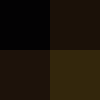

In [5]:
image = RayTracing.render(
    I, 
    scene, 
    parsed_args,
    (-1, -1)
)